# Replication PCA Loading Search

This notebook tries to reproduce the five-component loading table from the pasted figure using the 16 selected stressor variables in `complete_env_taxa_chemical_Apr17.xlsx`.

The search follows the author's description as one candidate method:

- apply a chemical transformation first
- run PCA on the correlation matrix of the 16 variables
- compare both raw eigenvectors and eigenvalue-scaled loadings
- test with and without varimax rotation
- rank each result against a manually transcribed target table from the figure

In [1]:
from __future__ import annotations

import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from factor_analyzer.rotator import Rotator
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'complete_env_taxa_chemical_Apr17.xlsx'

POLLUTION_VARS = [
    'Co', 'Al', 'Ni', 'Mn', 'Fe', 'Cr', 'Cu', 'Hg',
    'Pb', 'Zn', 'total PCB', 'Cd', 'OCS', "p,p'-DDE", 'As', 'Ca',
]

DISPLAY_LABELS = {
    'total PCB': 'SumPCBs',
}

TARGET_LOADINGS = pd.DataFrame(
    [
        [0.91, 0.18, 0.16, 0.12, 0.04],
        [0.90, -0.04, 0.02, 0.08, 0.19],
        [0.82, 0.50, 0.13, 0.14, 0.06],
        [0.74, 0.38, 0.16, 0.15, 0.36],
        [0.72, 0.41, 0.10, 0.15, 0.11],
        [0.71, 0.62, 0.10, 0.13, 0.03],
        [0.65, 0.64, 0.03, 0.14, 0.02],
        [-0.03, 0.81, 0.08, -0.07, 0.17],
        [0.42, 0.80, 0.07, 0.17, 0.02],
        [0.55, 0.71, 0.07, -0.02, 0.06],
        [0.27, 0.65, 0.44, 0.18, -0.21],
        [0.34, 0.58, 0.18, 0.55, 0.04],
        [0.05, 0.02, 0.86, 0.00, 0.30],
        [0.31, 0.34, 0.66, 0.07, -0.35],
        [0.13, 0.05, 0.00, 0.96, 0.03],
        [0.34, 0.09, 0.12, 0.06, 0.84],
    ],
    index=POLLUTION_VARS,
    columns=[f'PC{i}' for i in range(1, 6)],
)
TARGET_LOADINGS.index.name = 'Variable'

In [2]:
study_data = pd.read_excel(DATA_PATH, header=[0, 1, 2], index_col=0)
chemical_block = study_data.loc[:, ('chemical', 'raw', slice(None))].copy()
chemical_block.columns = chemical_block.columns.get_level_values(-1)

pollution_raw = chemical_block[POLLUTION_VARS].apply(pd.to_numeric, errors='coerce')
pollution_complete = pollution_raw.dropna().copy()
pollution_complete.index.name = 'StationID'

summary_table = pollution_complete.describe().T[['mean', 'std', 'min', '50%', 'max']].round(3)
summary_table = summary_table.rename(columns={'50%': 'median'})

print(f'Data path: {DATA_PATH}')
print(f'Chemical block shape: {chemical_block.shape}')
print(f'16-variable pollution matrix shape before complete-case filtering: {pollution_raw.shape}')
print(f'Rows retained for PCA after complete-case filtering: {pollution_complete.shape[0]}')
print(f'Rows dropped because of missing values: {pollution_raw.shape[0] - pollution_complete.shape[0]}')

display(summary_table)

Data path: /Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/Project_Code/data/processed/complete_env_taxa_chemical_Apr17.xlsx
Chemical block shape: (311, 27)
16-variable pollution matrix shape before complete-case filtering: (311, 16)
Rows retained for PCA after complete-case filtering: 310
Rows dropped because of missing values: 1


,mean,std,min,median,max
var,,,,,
Co,5.948,2.777,1.455,5.400,14.488
Al,8272.557,6259.240,1397.000,5928.080,29257.989
Ni,23.373,44.904,2.097,14.740,686.121
Mn,245.103,224.815,33.164,195.166,2100.000
Fe,19073.698,17600.895,0.000,14780.866,143333.333
Cr,27.820,30.288,2.220,18.305,260.000
Cu,37.343,55.604,0.000,20.983,530.000
Hg,842.603,1495.615,0.002,0.652,6939.498
Pb,34.102,106.779,0.000,6.046,1100.000


In [3]:
def transform_data(df: pd.DataFrame, transform_name: str) -> pd.DataFrame:
    if transform_name == 'raw':
        return df.copy()
    if transform_name == 'log10p':
        return np.log10(df + 1.0)
    if transform_name == 'log2p':
        return np.log2(df + 1.0)
    if transform_name == 'ln1p':
        return np.log1p(df)
    raise ValueError(f'Unsupported transform: {transform_name}')


def prepare_matrix(df: pd.DataFrame, transform_name: str, matrix_type: str) -> pd.DataFrame:
    transformed = transform_data(df, transform_name).astype(float)
    prepared = transformed - transformed.mean(axis=0)
    if matrix_type == 'correlation':
        prepared = prepared / transformed.std(axis=0, ddof=1)
    elif matrix_type != 'covariance':
        raise ValueError(f'Unsupported matrix type: {matrix_type}')
    return prepared


def compute_loadings(
    prepared: pd.DataFrame,
    loading_kind: str,
    rotate: str,
    n_components: int = 5,
) -> dict[str, object]:
    pca = PCA(n_components=n_components)
    pca.fit(prepared)

    pc_names = [f'PC{i}' for i in range(1, n_components + 1)]
    eigenvectors = pd.DataFrame(pca.components_.T, index=prepared.columns, columns=pc_names)
    scaled = pd.DataFrame(
        pca.components_.T * np.sqrt(pca.explained_variance_),
        index=prepared.columns,
        columns=pc_names,
    )

    if loading_kind == 'eigenvector':
        loadings = eigenvectors.copy()
    elif loading_kind == 'scaled':
        loadings = scaled.copy()
    else:
        raise ValueError(f'Unsupported loading kind: {loading_kind}')

    if rotate == 'varimax':
        rotator = Rotator(method='varimax')
        loadings = pd.DataFrame(
            rotator.fit_transform(loadings.values),
            index=loadings.index,
            columns=loadings.columns,
        )
    elif rotate != 'none':
        raise ValueError(f'Unsupported rotation: {rotate}')

    return {
        'pca': pca,
        'eigenvectors': eigenvectors,
        'scaled_loadings': scaled,
        'loadings': loadings,
        'cumvar_5': float(pca.explained_variance_ratio_[:n_components].sum()),
        'explained_variance_ratio': pd.Series(pca.explained_variance_ratio_[:n_components], index=pc_names),
    }


def align_to_target(candidate: pd.DataFrame, target: pd.DataFrame) -> dict[str, object]:
    best = None
    for perm in itertools.permutations(candidate.columns):
        permuted = candidate.loc[:, perm].copy()
        for signs in itertools.product([-1, 1], repeat=candidate.shape[1]):
            signed = permuted * np.array(signs)
            rmse = float(np.sqrt(((signed.values - target.values) ** 2).mean()))
            abs_rmse = float(np.sqrt(((np.abs(signed.values) - np.abs(target.values)) ** 2).mean()))
            if best is None or (rmse, abs_rmse) < (best['rmse'], best['abs_rmse']):
                best = {
                    'rmse': rmse,
                    'abs_rmse': abs_rmse,
                    'aligned': signed.set_axis(target.columns, axis=1),
                    'column_order': list(perm),
                    'signs': list(signs),
                }
    return best


def evaluate_variant(
    df: pd.DataFrame,
    transform_name: str,
    matrix_type: str,
    loading_kind: str,
    rotate: str,
) -> dict[str, object]:
    prepared = prepare_matrix(df, transform_name, matrix_type)
    component_result = compute_loadings(prepared, loading_kind, rotate)
    alignment = align_to_target(component_result['loadings'], TARGET_LOADINGS)

    return {
        'transform': transform_name,
        'matrix': matrix_type,
        'loading_kind': loading_kind,
        'rotate': rotate,
        'cumvar_5': component_result['cumvar_5'],
        'explained_variance_ratio': component_result['explained_variance_ratio'],
        'raw_loadings': component_result['loadings'],
        'aligned_loadings': alignment['aligned'],
        'rmse': alignment['rmse'],
        'abs_rmse': alignment['abs_rmse'],
        'column_order': alignment['column_order'],
        'signs': alignment['signs'],
    }

In [4]:
candidate_variants = []
for transform_name in ['raw', 'log10p', 'log2p', 'ln1p']:
    for matrix_type in ['correlation', 'covariance']:
        for loading_kind in ['scaled', 'eigenvector']:
            for rotate in ['none', 'varimax']:
                candidate_variants.append(
                    evaluate_variant(
                        pollution_complete,
                        transform_name,
                        matrix_type,
                        loading_kind,
                        rotate,
                    )
                )

results_df = pd.DataFrame(
    [
        {
            'transform': result['transform'],
            'matrix': result['matrix'],
            'loading_kind': result['loading_kind'],
            'rotate': result['rotate'],
            'rmse': result['rmse'],
            'abs_rmse': result['abs_rmse'],
            'cumvar_5': result['cumvar_5'],
            'column_order': ' -> '.join(result['column_order']),
            'signs': result['signs'],
        }
        for result in candidate_variants
    ]
).sort_values(['rmse', 'abs_rmse']).reset_index(drop=True)
results_df.index = np.arange(1, len(results_df) + 1)
results_df.index.name = 'rank'

best_result = min(candidate_variants, key=lambda result: (result['rmse'], result['abs_rmse']))
author_result = next(
    result
    for result in candidate_variants
    if (
        result['transform'],
        result['matrix'],
        result['loading_kind'],
        result['rotate'],
    ) == ('log10p', 'correlation', 'scaled', 'varimax')
)
author_rank = int(results_df.index[
    (results_df['transform'] == 'log10p')
    & (results_df['matrix'] == 'correlation')
    & (results_df['loading_kind'] == 'scaled')
    & (results_df['rotate'] == 'varimax')
][0])

print('Top candidate methods ranked against the transcribed target loading table')
display(results_df.head(12).round({'rmse': 4, 'abs_rmse': 4, 'cumvar_5': 4}))

print(f"Best variant: transform={best_result['transform']}, matrix={best_result['matrix']}, loading_kind={best_result['loading_kind']}, rotate={best_result['rotate']}")
print(f"Best RMSE: {best_result['rmse']:.4f}")
print(f"Author-described method rank: {author_rank}")
print(f"Author-described method cumulative variance for the first five components: {author_result['cumvar_5'] * 100:.2f}%")
print('Log10, log2, and natural-log transforms tie under correlation-matrix PCA because standardization removes the constant base-scaling difference between those transforms.')

Top candidate methods ranked against the transcribed target loading table


,transform,matrix,loading_kind,rotate,rmse,abs_rmse,cumvar_5,column_order,signs
rank,,,,,,,,,
1,log10p,correlation,scaled,varimax,0.3121,0.2748,0.8354,PC3 -> PC1 -> PC5 -> PC4 -> PC2,"[1, 1, 1, 1, 1]"
2,ln1p,correlation,scaled,varimax,0.3121,0.2748,0.8354,PC3 -> PC1 -> PC5 -> PC4 -> PC2,"[1, 1, 1, 1, 1]"
3,log2p,correlation,scaled,varimax,0.3121,0.2748,0.8354,PC3 -> PC1 -> PC5 -> PC4 -> PC2,"[1, 1, 1, 1, 1]"
4,log10p,correlation,eigenvector,varimax,0.3301,0.2923,0.8354,PC1 -> PC2 -> PC5 -> PC3 -> PC4,"[1, -1, 1, -1, -1]"
5,log2p,correlation,eigenvector,varimax,0.3301,0.2923,0.8354,PC1 -> PC2 -> PC5 -> PC3 -> PC4,"[1, -1, 1, -1, -1]"
6,ln1p,correlation,eigenvector,varimax,0.3301,0.2923,0.8354,PC1 -> PC2 -> PC5 -> PC3 -> PC4,"[1, -1, 1, -1, -1]"
7,raw,correlation,scaled,varimax,0.3359,0.3071,0.7548,PC4 -> PC1 -> PC3 -> PC5 -> PC2,"[-1, 1, 1, -1, 1]"
8,log10p,correlation,eigenvector,none,0.3490,0.2980,0.8354,PC1 -> PC4 -> PC2 -> PC5 -> PC3,"[1, -1, -1, 1, 1]"
9,ln1p,correlation,eigenvector,none,0.3490,0.2980,0.8354,PC1 -> PC4 -> PC2 -> PC5 -> PC3,"[1, -1, -1, 1, 1]"


Best variant: transform=log10p, matrix=correlation, loading_kind=scaled, rotate=varimax
Best RMSE: 0.3121
Author-described method rank: 1
Author-described method cumulative variance for the first five components: 83.54%
Log10, log2, and natural-log transforms tie under correlation-matrix PCA because standardization removes the constant base-scaling difference between those transforms.


Column permutation needed to align the author-method PCA result to the target table:
['PC3', 'PC1', 'PC5', 'PC4', 'PC2']
Sign flips applied after column matching:
[1, 1, 1, 1, 1]
Per-component explained variance before rotation:


,explained_variance_percent
PC1,37.89
PC2,23.47
PC3,8.89
PC4,7.54
PC5,5.75


Target table, aligned best match from the author method, and signed difference:


target_from_image                         best_aligned_author_method  \
                       PC1   PC2   PC3   PC4   PC5                        PC1   
Co                    0.91  0.18  0.16  0.12  0.04                       0.73   
Al                    0.90 -0.04  0.02  0.08  0.19                       0.87   
Ni                    0.82  0.50  0.13  0.14  0.06                       0.24   
Mn                    0.74  0.38  0.16  0.15  0.36                       0.62   
Fe                    0.72  0.41  0.10  0.15  0.11                       0.55   
Cr                    0.71  0.62  0.10  0.13  0.03                       0.44   
Cu                    0.65  0.64  0.03  0.14  0.02                       0.39   
Hg                   -0.03  0.81  0.08 -0.07  0.17                       0.24   
Pb                    0.42  0.80  0.07  0.17  0.02                       0.03   
Zn                    0.55  0.71  0.07 -0.02  0.06                      -0.01   
SumPCBs               0.27  0.65  0.44  0.18 -0.21                      -0.15   
Cd                    0.34  0.58  0.18  0.55  0.04                       0.18   
OCS                   0.05  0.02  0.86  0.00  0.30                       0.09   
p,p'-DDE              0.31  0.34  0.66  0.07 -0.35                      -0.09   
As                    0.13  0.05  0.00  0.96  0.03                       0.22   
Ca                    0.34  0.09  0.12  0.06  0.84                       0.70   

                                 difference                              
           PC2   PC3   PC4   PC5        PC1    PC2    PC3    PC4    PC5  
Co        0.48 -0.05  0.13 -0.27     -0.179  0.304 -0.208  0.006 -0.312  
Al        0.25 -0.09  0.07 -0.12     -0.027  0.293 -0.107 -0.007 -0.307  
Ni        0.89  0.08  0.04  0.04     -0.577  0.387 -0.047 -0.102 -0.022  
Mn        0.42  0.06  0.28  0.45     -0.122  0.043 -0.097  0.134  0.086  
Fe        0.39 -0.02  0.10 -0.02     -0.171 -0.015 -0.120 -0.052 -0.129  
Cr        0.82 -0.13  0.23 -0.03     -0.266  0.195 -0.227  0.098 -0.063  
Cu        0.79 -0.13  0.20 -0.08     -0.259  0.154 -0.157  0.056 -0.098  
Hg       -0.01 -0.04  0.20 -0.92      0.267 -0.822 -0.123  0.271 -1.091  
Pb        0.40 -0.05  0.70  0.52     -0.386 -0.400 -0.119  0.527  0.499  
Zn        0.30  0.01 -0.06  0.94     -0.556 -0.412 -0.058 -0.039  0.877  
SumPCBs   0.36  0.28 -0.05 -0.80     -0.417 -0.287 -0.158 -0.234 -0.594  
Cd        0.65 -0.02  0.55 -0.11     -0.164  0.070 -0.196 -0.000 -0.153  
OCS      -0.09  0.90 -0.07 -0.22      0.037 -0.109  0.041 -0.072 -0.522  
p,p'-DDE  0.34  0.24 -0.09 -0.77     -0.396  0.002 -0.420 -0.160 -0.423  
As        0.11 -0.06  0.91 -0.21      0.085  0.059 -0.061 -0.055 -0.237  
Ca        0.06  0.31  0.09  0.18      0.362 -0.031  0.186  0.028 -0.662

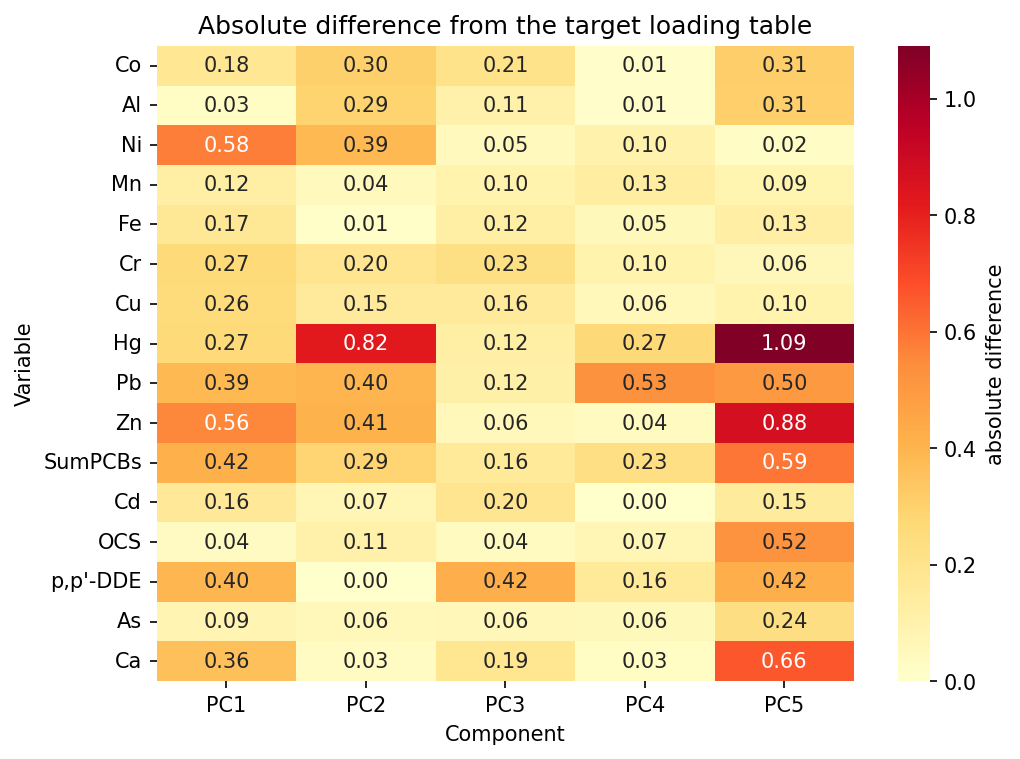

In [5]:
target_display = TARGET_LOADINGS.rename(index=DISPLAY_LABELS).round(2)
author_display = author_result['aligned_loadings'].rename(index=DISPLAY_LABELS).round(2)
difference_display = (author_result['aligned_loadings'] - TARGET_LOADINGS).rename(index=DISPLAY_LABELS).round(3)

comparison_table = pd.concat(
    {
        'target_from_image': target_display,
        'best_aligned_author_method': author_display,
        'difference': difference_display,
    },
    axis=1,
)

print('Column permutation needed to align the author-method PCA result to the target table:')
print(author_result['column_order'])
print('Sign flips applied after column matching:')
print(author_result['signs'])
print('Per-component explained variance before rotation:')
display((author_result['explained_variance_ratio'] * 100).round(2).to_frame('explained_variance_percent'))
print('Target table, aligned best match from the author method, and signed difference:')
display(comparison_table)

fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=150)
sns.heatmap(
    difference_display.abs(),
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'absolute difference'},
    ax=ax,
)
ax.set_title('Absolute difference from the target loading table')
ax.set_xlabel('Component')
ax.set_ylabel('Variable')
plt.show()

In [6]:
log10_plus1_data = np.log10(pollution_complete + 1.0)
correlation_matrix_log10 = log10_plus1_data.corr()

eigenvalues, eigenvectors = np.linalg.eigh(correlation_matrix_log10.to_numpy())
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

for column_index in range(eigenvectors.shape[1]):
    dominant_row = np.abs(eigenvectors[:, column_index]).argmax()
    if eigenvectors[dominant_row, column_index] < 0:
        eigenvectors[:, column_index] *= -1

pc_names = [f'PC{i}' for i in range(1, len(eigenvalues) + 1)]
eigenvalue_summary = pd.DataFrame(
    {
        'eigenvalue': eigenvalues,
        'proportion_of_variance': eigenvalues / eigenvalues.sum(),
        'cumulative_proportion': np.cumsum(eigenvalues / eigenvalues.sum()),
    },
    index=pc_names,
)

eigenvector_df = pd.DataFrame(eigenvectors, index=POLLUTION_VARS, columns=pc_names)
eigenvector_df.index.name = 'Variable'

eigenvector_top5_display = eigenvector_df.iloc[:, :5].rename(index=DISPLAY_LABELS).round(4)
full_eigenvector_display = eigenvector_df.rename(index=DISPLAY_LABELS).round(4)

print('Applied log10(x + 1) transformation to the 16 chemical variables.')
print('Ran PCA by eigendecomposition of the correlation matrix of the transformed data.')
print('Top 5 eigenvalues and explained variance proportions:')
display(eigenvalue_summary.iloc[:5].round(4))
print('Top 5 eigenvectors (one column per principal component):')
display(eigenvector_top5_display)
print('Full eigenvector matrix:')
display(full_eigenvector_display)

Applied log10(x + 1) transformation to the 16 chemical variables.
Ran PCA by eigendecomposition of the correlation matrix of the transformed data.
Top 5 eigenvalues and explained variance proportions:


,eigenvalue,proportion_of_variance,cumulative_proportion
PC1,6.0625,0.3789,0.3789
PC2,3.7548,0.2347,0.6136
PC3,1.4227,0.0889,0.7025
PC4,1.2062,0.0754,0.7779
PC5,0.9197,0.0575,0.8354


Top 5 eigenvectors (one column per principal component):


,PC1,PC2,PC3,PC4,PC5
Variable,,,,,
Co,0.3422,-0.1194,0.2022,0.0935,-0.1755
Al,0.2998,-0.0380,0.3512,0.2582,-0.2251
Ni,0.3191,0.0164,-0.0272,-0.4426,-0.0034
Mn,0.3061,0.2389,0.1719,0.0785,0.1146
Fe,0.2630,0.0029,0.1657,0.0336,-0.0947
Cr,0.3786,0.0087,-0.0750,-0.1717,-0.1408
Cu,0.3555,-0.0158,-0.0881,-0.1915,-0.1512
Hg,0.1017,-0.4524,-0.0602,0.2910,-0.0998
Pb,0.2173,0.2945,-0.3785,0.0872,0.3198


Full eigenvector matrix:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
Variable,,,,,,,,,,,,,,,,
Co,0.3422,-0.1194,0.2022,0.0935,-0.1755,-0.3592,0.0435,-0.0233,0.1491,-0.1585,0.0344,0.2251,-0.2807,0.4794,-0.4974,-0.0395
Al,0.2998,-0.0380,0.3512,0.2582,-0.2251,-0.3595,0.0842,0.1029,0.0441,0.0114,-0.4476,0.1720,0.1986,-0.3735,0.3313,0.0186
Ni,0.3191,0.0164,-0.0272,-0.4426,-0.0034,0.0482,-0.1651,0.1101,-0.3851,-0.4129,-0.3685,-0.3693,0.0990,-0.0617,-0.2280,0.0544
Mn,0.3061,0.2389,0.1719,0.0785,0.1146,-0.0469,-0.0398,0.3946,0.1349,-0.2271,0.6584,-0.1256,0.1700,-0.2910,-0.0602,-0.0678
Fe,0.2630,0.0029,0.1657,0.0336,-0.0947,0.5574,0.7407,0.0379,-0.1336,0.0798,-0.0206,0.0129,-0.0447,0.0276,-0.0583,-0.0395
Cr,0.3786,0.0087,-0.0750,-0.1717,-0.1408,-0.0693,-0.0339,-0.1832,-0.0208,0.0747,0.2017,-0.1753,0.2298,0.5250,0.5894,-0.0942
Cu,0.3555,-0.0158,-0.0881,-0.1915,-0.1512,-0.0965,-0.1376,-0.3223,-0.2293,0.5016,0.2024,-0.0118,-0.3718,-0.4133,-0.0980,-0.0996
Hg,0.1017,-0.4524,-0.0602,0.2910,-0.0998,0.0627,-0.0543,-0.2116,-0.0784,0.0611,0.1827,-0.1552,0.3739,-0.0405,-0.1963,0.6227
Pb,0.2173,0.2945,-0.3785,0.0872,0.3198,-0.1150,0.0615,0.0545,-0.0824,0.3465,-0.1619,0.2435,0.5073,0.0936,-0.3064,-0.1434


In [7]:
scaled_by_eigenvalue_df = eigenvector_df.mul(eigenvalues, axis=1)
scaled_by_eigenvalue_df.index.name = 'Variable'

scaled_top5_display = scaled_by_eigenvalue_df.iloc[:, :5].rename(index=DISPLAY_LABELS).round(4)
full_scaled_display = scaled_by_eigenvalue_df.rename(index=DISPLAY_LABELS).round(4)

print('Scaled the PCA eigenvectors by their corresponding eigenvalues.')
print('Top 5 eigenvalue-scaled eigenvectors:')
display(scaled_top5_display)
print('Full eigenvalue-scaled eigenvector matrix:')
display(full_scaled_display)

Scaled the PCA eigenvectors by their corresponding eigenvalues.
Top 5 eigenvalue-scaled eigenvectors:


,PC1,PC2,PC3,PC4,PC5
Variable,,,,,
Co,2.0747,-0.4483,0.2876,0.1127,-0.1614
Al,1.8178,-0.1425,0.4996,0.3115,-0.2070
Ni,1.9345,0.0617,-0.0387,-0.5339,-0.0032
Mn,1.8560,0.8972,0.2445,0.0947,0.1054
Fe,1.5943,0.0109,0.2357,0.0405,-0.0871
Cr,2.2953,0.0326,-0.1067,-0.2071,-0.1295
Cu,2.1555,-0.0595,-0.1254,-0.2310,-0.1391
Hg,0.6163,-1.6988,-0.0856,0.3510,-0.0918
Pb,1.3171,1.1058,-0.5384,0.1052,0.2941


Full eigenvalue-scaled eigenvector matrix:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
Variable,,,,,,,,,,,,,,,,
Co,2.0747,-0.4483,0.2876,0.1127,-0.1614,-0.2343,0.0255,-0.0088,0.0435,-0.0329,0.0053,0.0309,-0.0271,0.0337,-0.0229,-0.0005
Al,1.8178,-0.1425,0.4996,0.3115,-0.2070,-0.2345,0.0494,0.0389,0.0129,0.0024,-0.0697,0.0236,0.0192,-0.0262,0.0152,0.0002
Ni,1.9345,0.0617,-0.0387,-0.5339,-0.0032,0.0314,-0.0968,0.0416,-0.1123,-0.0858,-0.0574,-0.0507,0.0096,-0.0043,-0.0105,0.0007
Mn,1.8560,0.8972,0.2445,0.0947,0.1054,-0.0306,-0.0234,0.1491,0.0393,-0.0472,0.1025,-0.0172,0.0164,-0.0204,-0.0028,-0.0008
Fe,1.5943,0.0109,0.2357,0.0405,-0.0871,0.3636,0.4344,0.0143,-0.0390,0.0166,-0.0032,0.0018,-0.0043,0.0019,-0.0027,-0.0005
Cr,2.2953,0.0326,-0.1067,-0.2071,-0.1295,-0.0452,-0.0199,-0.0692,-0.0061,0.0155,0.0314,-0.0241,0.0222,0.0369,0.0271,-0.0011
Cu,2.1555,-0.0595,-0.1254,-0.2310,-0.1391,-0.0629,-0.0807,-0.1218,-0.0669,0.1042,0.0315,-0.0016,-0.0359,-0.0290,-0.0045,-0.0012
Hg,0.6163,-1.6988,-0.0856,0.3510,-0.0918,0.0409,-0.0319,-0.0800,-0.0229,0.0127,0.0284,-0.0213,0.0361,-0.0028,-0.0090,0.0075
Pb,1.3171,1.1058,-0.5384,0.1052,0.2941,-0.0750,0.0361,0.0206,-0.0240,0.0720,-0.0252,0.0334,0.0490,0.0066,-0.0141,-0.0017
